In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fndds-csv-dataset/fndda-csv-dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

# Load the dataset
file_path = '/kaggle/input/fndds-csv-dataset/fndda-csv-dataset.csv'  
df = pd.read_csv(file_path)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5431 entries, 0 to 5430
Data columns (total 69 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Food code                               5431 non-null   int64  
 1   Main food description                   5431 non-null   object 
 2   WWEIA Category number                   5431 non-null   int64  
 3   WWEIA Category description              5431 non-null   object 
 4   Energy (kcal)                           5431 non-null   int64  
 5   Protein (g)                             5431 non-null   float64
 6   Carbohydrate (g)                        5431 non-null   float64
 7   Sugars, total
(g)                       5431 non-null   float64
 8   Fiber, total dietary (g)                5431 non-null   float64
 9   Total Fat (g)                           5431 non-null   float64
 10  Fatty acids, total saturated (g)        5431 non-null   floa

In [5]:
df.head()

,Food code,Main food description,WWEIA Category number,WWEIA Category description,Energy (kcal),Protein (g),Carbohydrate (g),"Sugars, total\n(g)","Fiber, total dietary (g)",Total Fat (g),...,20:1\n(g),22:1\n(g),18:2\n(g),18:3\n(g),18:4\n(g),20:4\n(g),20:5 n-3\n(g),22:5 n-3\n(g),22:6 n-3\n(g),Water\n(g)
0,11100000,"Milk, NFS",1004,"Milk, reduced fat",52,3.33,4.83,4.88,0.0,2.14,...,0.002,0.0,0.074,0.008,0.0,0.003,0.000,0.001,0.0,88.92
1,11111000,"Milk, whole",1002,"Milk, whole",61,3.27,4.63,4.81,0.0,3.20,...,0.004,0.0,0.115,0.013,0.0,0.004,0.001,0.002,0.0,88.10
2,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",50,3.36,4.90,4.89,0.0,1.90,...,0.002,0.0,0.061,0.007,0.0,0.003,0.000,0.001,0.0,89.10
3,11112210,"Milk, low fat (1%)",1006,"Milk, lowfat",43,3.38,5.18,4.96,0.0,0.95,...,0.001,0.0,0.033,0.004,0.0,0.001,0.000,0.000,0.0,89.70
4,11113000,"Milk, fat free (skim)",1008,"Milk, nonfat",34,3.43,4.92,5.05,0.0,0.08,...,0.000,0.0,0.005,0.000,0.0,0.000,0.000,0.000,0.0,90.80


In [6]:
df.describe()

,Food code,WWEIA Category number,Energy (kcal),Protein (g),Carbohydrate (g),"Sugars, total\n(g)","Fiber, total dietary (g)",Total Fat (g),"Fatty acids, total saturated (g)","Fatty acids, total monounsaturated (g)",...,20:1\n(g),22:1\n(g),18:2\n(g),18:3\n(g),18:4\n(g),20:4\n(g),20:5 n-3\n(g),22:5 n-3\n(g),22:6 n-3\n(g),Water\n(g)
count,5.431000e+03,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,...,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000
mean,5.077471e+07,4743.645185,199.251703,8.161322,20.857490,6.842869,1.745516,9.292324,2.819773,3.295595,...,0.037994,0.004593,1.996105,0.205847,0.001154,0.013860,0.007610,0.003680,0.011756,59.865489
std,2.405806e+07,2147.030148,142.695564,7.777699,21.131991,12.131206,2.427976,11.576625,4.080434,4.910464,...,0.105338,0.078441,3.702443,0.902634,0.009064,0.032344,0.059968,0.019135,0.088470,26.490616
min,1.110000e+07,1002.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.741514e+07,3004.000000,91.500000,2.200000,5.740000,0.710000,0.200000,2.120000,0.457000,0.521500,...,0.001000,0.000000,0.243500,0.029000,0.000000,0.000000,0.000000,0.000000,0.000000,46.015000
50%,5.371110e+07,4202.000000,167.000000,6.140000,14.480000,2.330000,1.100000,6.000000,1.511000,1.967000,...,0.015000,0.000000,0.941000,0.095000,0.000000,0.002000,0.000000,0.000000,0.000000,67.160000
75%,7.140100e+07,6418.000000,273.000000,11.525000,26.550000,7.040000,2.200000,13.045000,3.768500,4.458500,...,0.040000,0.000000,2.222000,0.198000,0.000000,0.014000,0.001000,0.002000,0.000000,79.360000
max,9.999821e+07,9999.000000,902.000000,78.130000,100.000000,99.800000,42.800000,100.000000,82.500000,71.600000,...,3.648000,5.166000,54.800000,53.368000,0.224000,0.505000,2.741000,0.391000,3.800000,99.980000


In [7]:
print(df.isnull().sum())

Food code                     0
Main food description         0
WWEIA Category number         0
WWEIA Category description    0
Energy (kcal)                 0
                             ..
20:4\n(g)                     0
20:5 n-3\n(g)                 0
22:5 n-3\n(g)                 0
22:6 n-3\n(g)                 0
Water\n(g)                    0
Length: 69, dtype: int64


In [8]:
df.columns = [col.strip().replace("\n", " ").replace(" ", "_").lower() for col in df.columns]
print(df.columns)

Index(['food_code', 'main_food_description', 'wweia_category_number',
       'wweia_category_description', 'energy_(kcal)', 'protein_(g)',
       'carbohydrate_(g)', 'sugars,_total_(g)', 'fiber,_total_dietary_(g)',
       'total_fat_(g)', 'fatty_acids,_total_saturated_(g)',
       'fatty_acids,_total_monounsaturated_(g)',
       'fatty_acids,_total_polyunsaturated_(g)', 'cholesterol_(mg)',
       'retinol_(mcg)', 'vitamin_a,_rae_(mcg_rae)', 'carotene,_alpha_(mcg)',
       'carotene,_beta_(mcg)', 'cryptoxanthin,_beta_(mcg)', 'lycopene_(mcg)',
       'lutein_+_zeaxanthin_(mcg)', 'thiamin_(mg)', 'riboflavin_(mg)',
       'niacin_(mg)', 'vitamin_b-6_(mg)', 'folic_acid_(mcg)',
       'folate,_food_(mcg)', 'folate,_dfe_(mcg_dfe)', 'folate,_total_(mcg)',
       'choline,_total_(mg)', 'vitamin_b-12_(mcg)',
       'vitamin_b-12,_added_(mcg)', 'vitamin_c_(mg)',
       'vitamin_d_(d2_+_d3)_(mcg)', 'vitamin_e_(alpha-tocopherol)_(mg)',
       'vitamin_e,_added_(mg)', 'vitamin_k_(phylloquinone)_(mcg

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


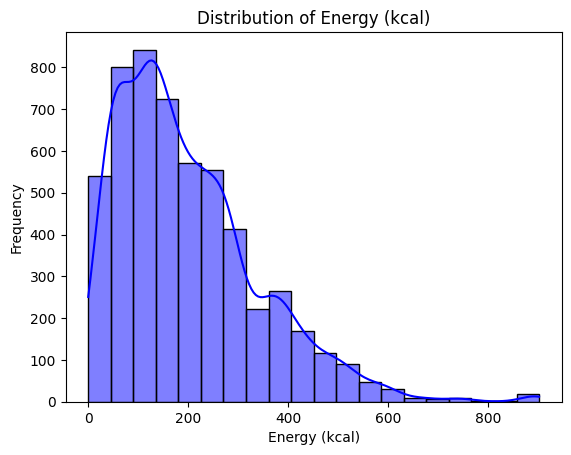

In [9]:
sns.histplot(df['energy_(kcal)'], bins=20, kde=True, color='blue')
plt.title('Distribution of Energy (kcal)')
plt.xlabel('Energy (kcal)')
plt.ylabel('Frequency')
plt.show()


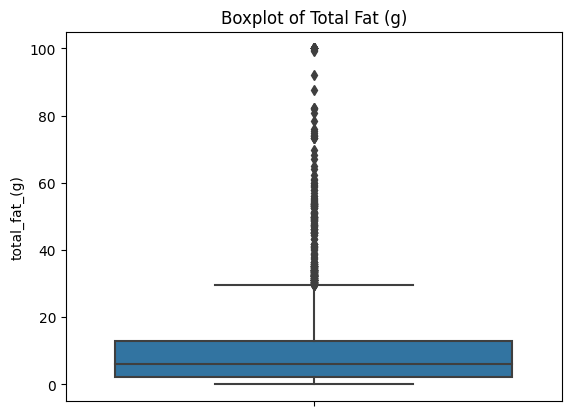

In [10]:
sns.boxplot(data=df, y='total_fat_(g)')
plt.title('Boxplot of Total Fat (g)')
plt.show()


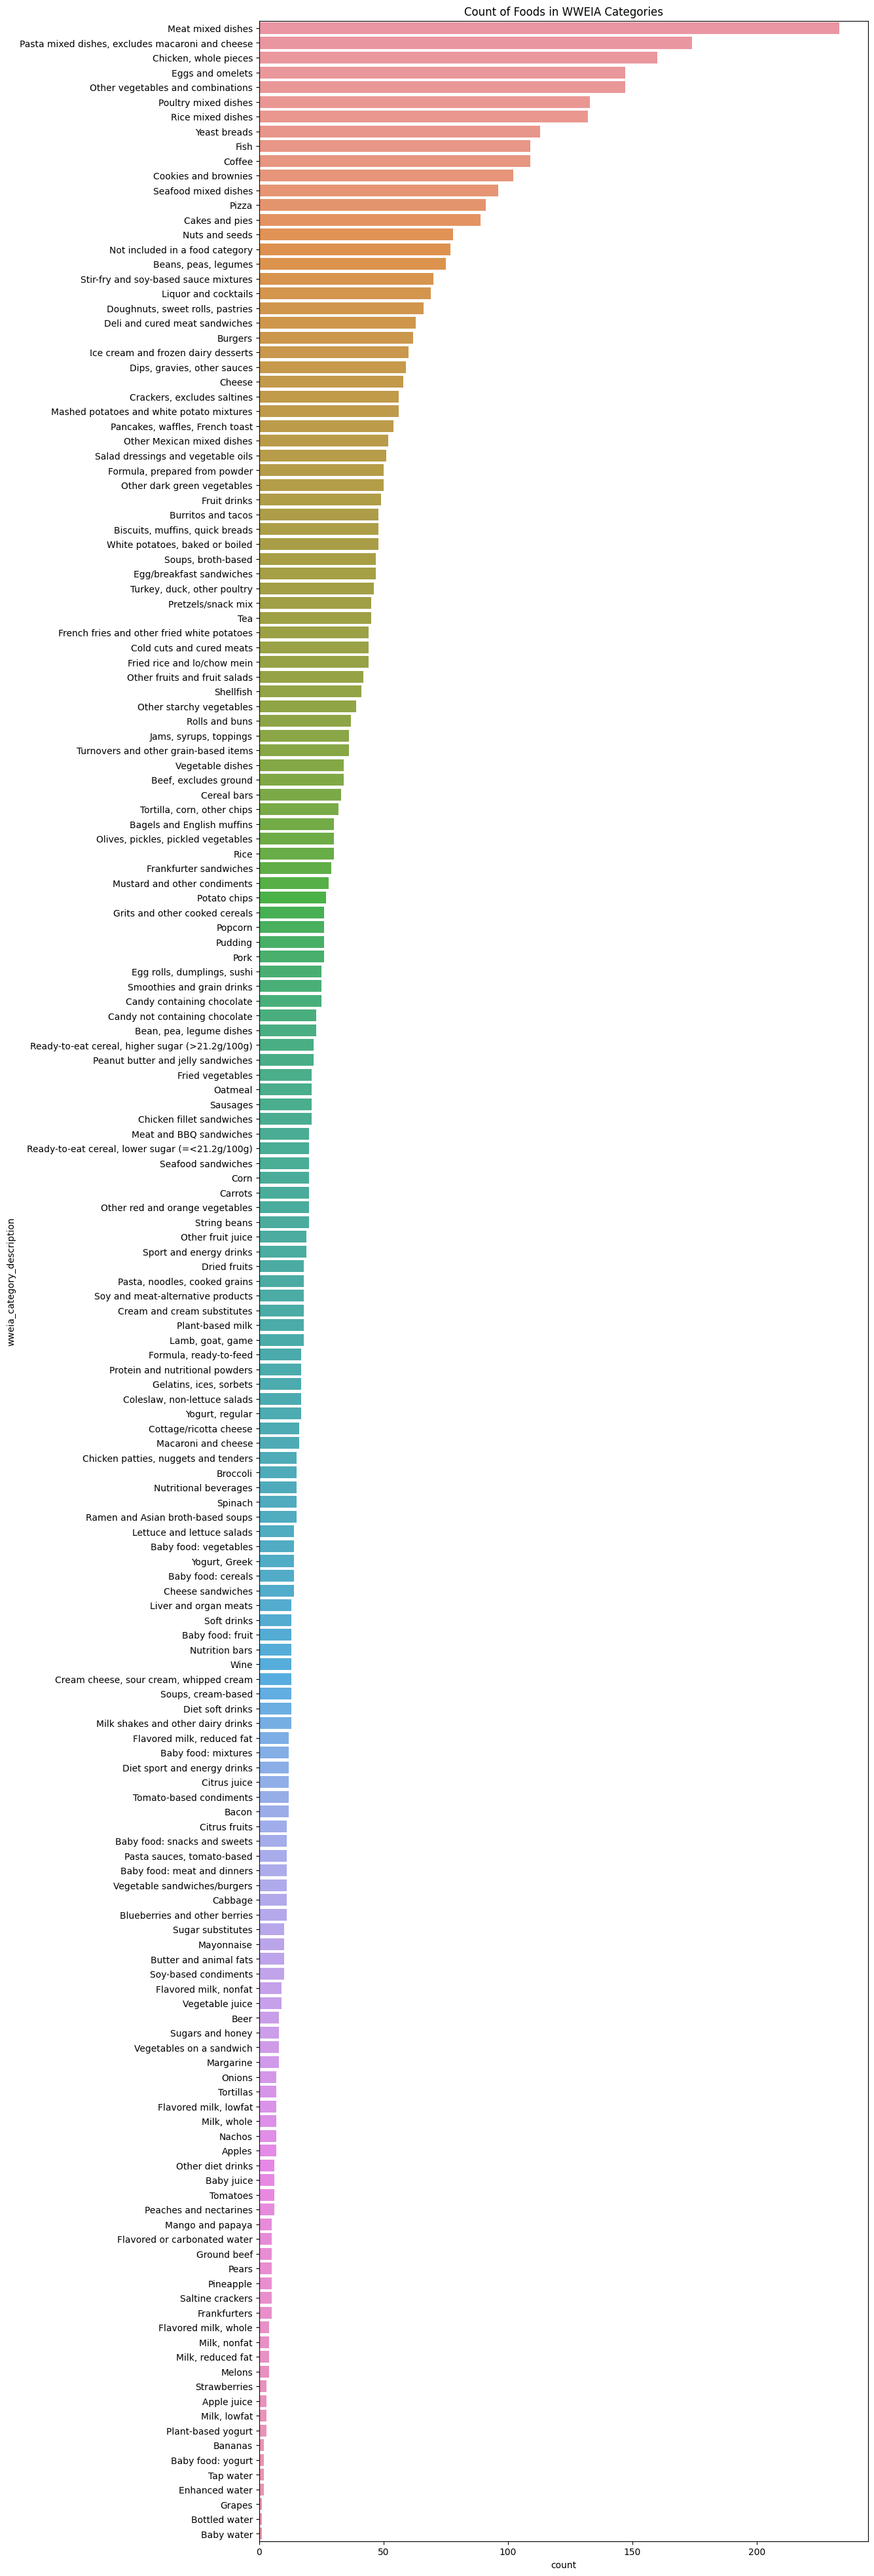

In [11]:
plt.figure(figsize=(12, 50))
sns.countplot(data=df, y='wweia_category_description', order=df['wweia_category_description'].value_counts().index)
plt.title('Count of Foods in WWEIA Categories')
plt.show()


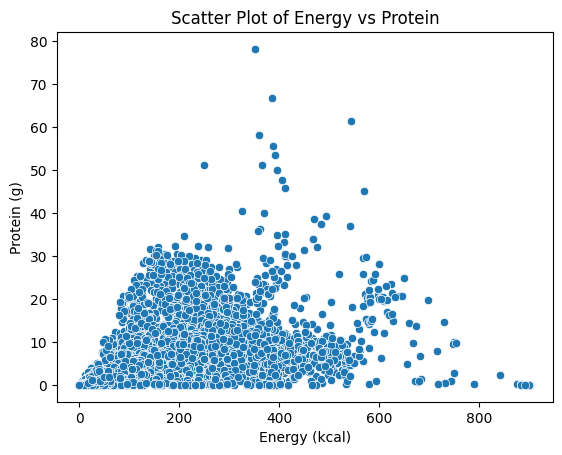

In [12]:
sns.scatterplot(data=df, x='energy_(kcal)', y='protein_(g)')
plt.title('Scatter Plot of Energy vs Protein')
plt.xlabel('Energy (kcal)')
plt.ylabel('Protein (g)')
plt.show()


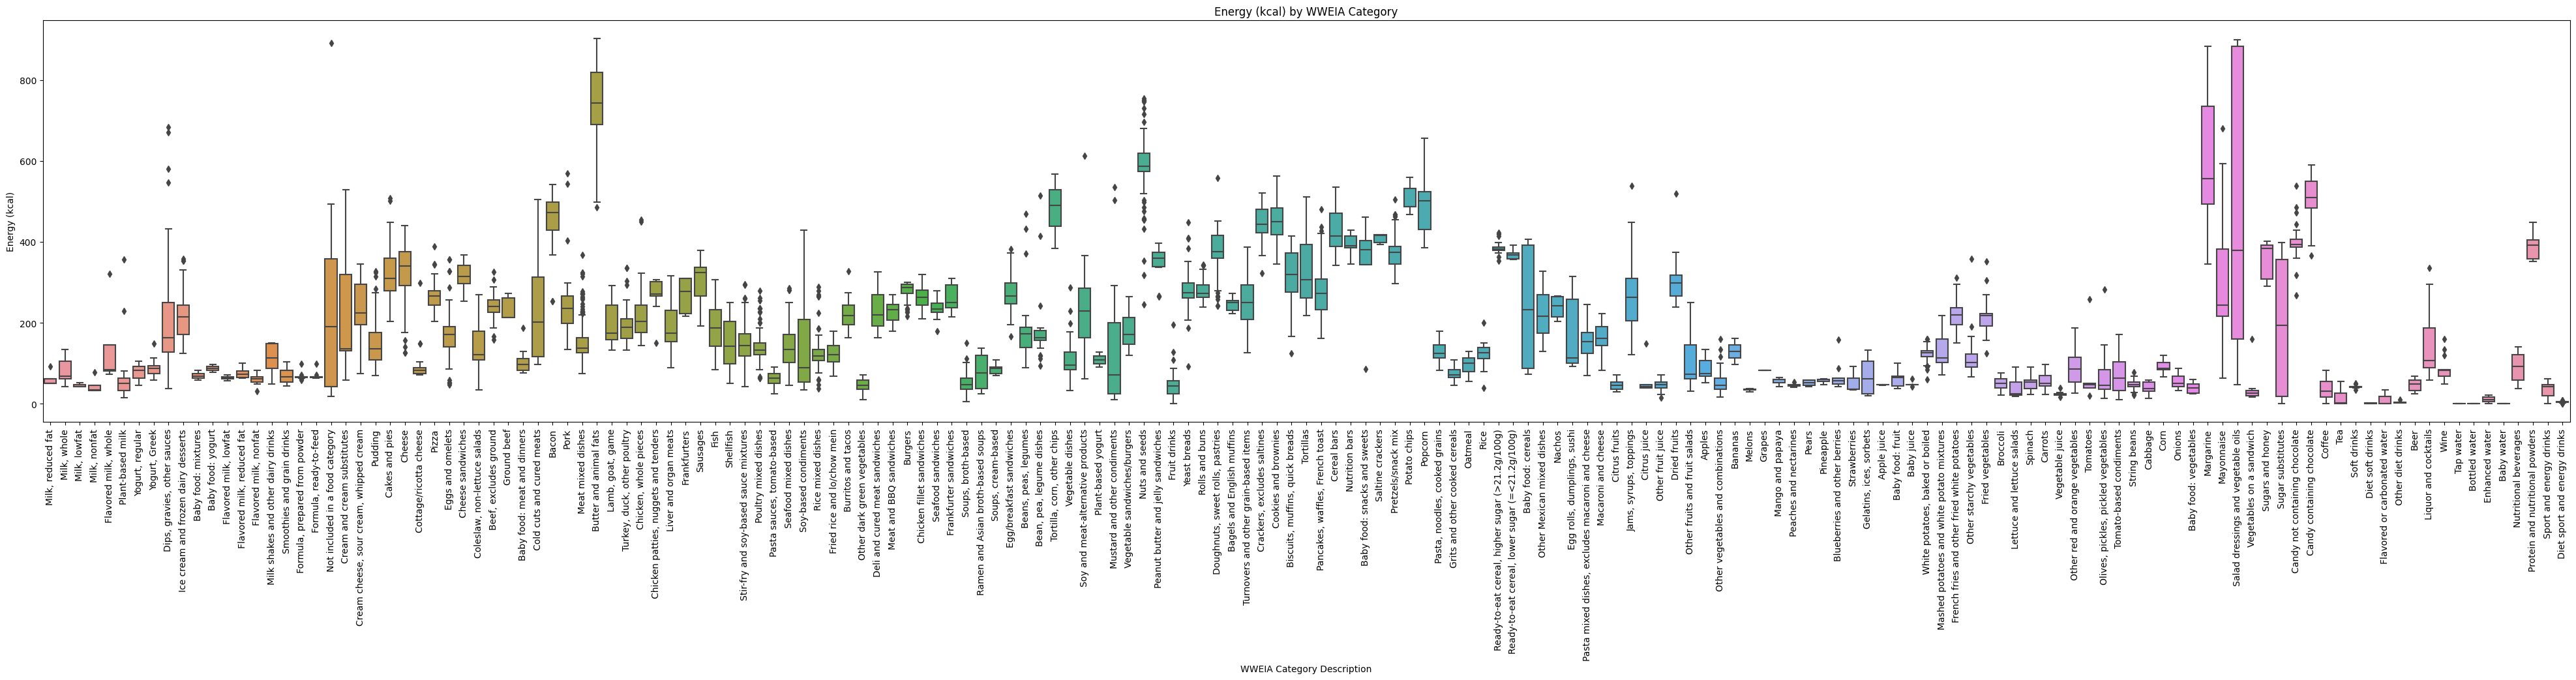

In [13]:
# Boxplot for energy (kcal) by WWEIA category, flipped for clarity
plt.figure(figsize=(50, 8))
sns.boxplot(data=df
            , y='energy_(kcal)', x='wweia_category_description')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Energy (kcal) by WWEIA Category')
plt.xlabel('WWEIA Category Description')
plt.ylabel('Energy (kcal)')
plt.show()


In [14]:
df.columns

Index(['food_code', 'main_food_description', 'wweia_category_number',
       'wweia_category_description', 'energy_(kcal)', 'protein_(g)',
       'carbohydrate_(g)', 'sugars,_total_(g)', 'fiber,_total_dietary_(g)',
       'total_fat_(g)', 'fatty_acids,_total_saturated_(g)',
       'fatty_acids,_total_monounsaturated_(g)',
       'fatty_acids,_total_polyunsaturated_(g)', 'cholesterol_(mg)',
       'retinol_(mcg)', 'vitamin_a,_rae_(mcg_rae)', 'carotene,_alpha_(mcg)',
       'carotene,_beta_(mcg)', 'cryptoxanthin,_beta_(mcg)', 'lycopene_(mcg)',
       'lutein_+_zeaxanthin_(mcg)', 'thiamin_(mg)', 'riboflavin_(mg)',
       'niacin_(mg)', 'vitamin_b-6_(mg)', 'folic_acid_(mcg)',
       'folate,_food_(mcg)', 'folate,_dfe_(mcg_dfe)', 'folate,_total_(mcg)',
       'choline,_total_(mg)', 'vitamin_b-12_(mcg)',
       'vitamin_b-12,_added_(mcg)', 'vitamin_c_(mg)',
       'vitamin_d_(d2_+_d3)_(mcg)', 'vitamin_e_(alpha-tocopherol)_(mg)',
       'vitamin_e,_added_(mg)', 'vitamin_k_(phylloquinone)_(mcg

In [16]:
# List of columns you want to keep
selected_columns = ['food_code', 'main_food_description', 'wweia_category_description', 
                    'energy_(kcal)', 'protein_(g)', 'carbohydrate_(g)', 
                    'sugars,_total_(g)', 'fiber,_total_dietary_(g)', 'total_fat_(g)', 
                    'fatty_acids,_total_saturated_(g)',
                    'fatty_acids,_total_monounsaturated_(g)',
                    'fatty_acids,_total_polyunsaturated_(g)', 'cholesterol_(mg)']


In [17]:
# Create a new dataset with only these columns
new_data = df[selected_columns]


In [18]:
new_data.head()

,food_code,main_food_description,wweia_category_description,energy_(kcal),protein_(g),carbohydrate_(g),"sugars,_total_(g)","fiber,_total_dietary_(g)",total_fat_(g),"fatty_acids,_total_saturated_(g)","fatty_acids,_total_monounsaturated_(g)","fatty_acids,_total_polyunsaturated_(g)",cholesterol_(mg)
0,11100000,"Milk, NFS","Milk, reduced fat",52,3.33,4.83,4.88,0.0,2.14,1.249,0.458,0.070,9
1,11111000,"Milk, whole","Milk, whole",61,3.27,4.63,4.81,0.0,3.20,1.860,0.688,0.108,12
2,11112110,"Milk, reduced fat (2%)","Milk, reduced fat",50,3.36,4.90,4.89,0.0,1.90,1.110,0.400,0.058,8
3,11112210,"Milk, low fat (1%)","Milk, lowfat",43,3.38,5.18,4.96,0.0,0.95,0.568,0.210,0.032,5
4,11113000,"Milk, fat free (skim)","Milk, nonfat",34,3.43,4.92,5.05,0.0,0.08,0.049,0.017,0.006,3


In [20]:
# Save the new dataset to a CSV file 
new_data.to_csv('/kaggle/working/fnnds_selected_columns_dataset.csv', index=False)
print("New dataset saved as 'selected_columns_dataset.csv'")

New dataset saved as 'selected_columns_dataset.csv'
